In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    roc_curve
)

from imblearn.over_sampling import SMOTE

In [2]:
df = pd.read_csv("creditcard.csv")

FileNotFoundError: [Errno 2] No such file or directory: 'creditcard.csv'

In [3]:
df = pd.read_csv("creditcard.csv")

In [4]:
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0.0
1,0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0.0
2,1,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0.0
3,1,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0.0
4,2,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0.0


In [5]:
df.shape

(93181, 31)

In [6]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class'],
      dtype='object')

In [7]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [8]:
df.isnull().sum()[df.isnull().sum() > 0]

,0
V13,1
V14,1
V15,1
V16,1
V17,1
V18,1
V19,1
V20,1
V21,1
V22,1


In [9]:
df.shape

(93181, 31)

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 93181 entries, 0 to 93180
Data columns (total 31 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   Time    93181 non-null  int64  
 1   V1      93181 non-null  float64
 2   V2      93181 non-null  float64
 3   V3      93181 non-null  float64
 4   V4      93181 non-null  float64
 5   V5      93181 non-null  float64
 6   V6      93181 non-null  float64
 7   V7      93181 non-null  float64
 8   V8      93181 non-null  float64
 9   V9      93181 non-null  float64
 10  V10     93181 non-null  float64
 11  V11     93181 non-null  float64
 12  V12     93181 non-null  float64
 13  V13     93180 non-null  float64
 14  V14     93180 non-null  float64
 15  V15     93180 non-null  float64
 16  V16     93180 non-null  float64
 17  V17     93180 non-null  float64
 18  V18     93180 non-null  float64
 19  V19     93180 non-null  float64
 20  V20     93180 non-null  float64
 21  V21     93180 non-null  float64
 22

In [11]:
df.describe()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
count,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,93181.000000,...,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000,93180.000000
mean,40720.460405,-0.263002,-0.040780,0.676306,0.163064,-0.280078,0.093917,-0.108816,0.055540,-0.036898,...,-0.029999,-0.107373,-0.037835,0.009540,0.132163,0.026936,0.001515,0.002321,99.030945,0.002286
std,16392.444505,1.869011,1.664308,1.341575,1.355105,1.368687,1.303615,1.225238,1.209672,1.123318,...,0.723135,0.634840,0.640783,0.594557,0.442183,0.495719,0.389447,0.324150,268.350415,0.047757
min,0.000000,-56.407510,-72.715728,-33.680984,-5.172595,-42.147898,-26.160506,-31.764946,-73.216718,-9.283925,...,-34.830382,-10.933144,-44.807735,-2.836627,-10.295397,-2.534330,-9.390980,-9.617915,0.000000,0.000000
25%,32678.000000,-1.028016,-0.605706,0.179018,-0.716783,-0.898708,-0.647692,-0.600859,-0.139122,-0.695859,...,-0.224205,-0.528068,-0.177280,-0.322364,-0.132298,-0.325627,-0.062925,-0.005614,7.600000,0.000000
50%,42848.000000,-0.258489,0.072818,0.756532,0.189117,-0.314928,-0.156536,-0.069893,0.072409,-0.109294,...,-0.057606,-0.082454,-0.049500,0.064890,0.170764,-0.070610,0.009579,0.023267,26.945000,0.000000
75%,53622.000000,1.153021,0.728656,1.381324,1.034477,0.250915,0.487658,0.415870,0.357253,0.576494,...,0.119664,0.309217,0.081457,0.406029,0.420096,0.304235,0.082701,0.076475,89.990000,0.000000
max,64283.000000,1.960497,18.902453,4.226108,16.715537,34.801666,22.529298,36.677268,20.007208,10.392889,...,22.614889,10.503090,18.946734,4.014444,5.541598,3.517346,12.152401,33.847808,19656.530000,1.000000


In [12]:
df["Class"].value_counts()

,count
Class,
0.0,92967
1.0,213


In [13]:
fraud = df["Class"].value_counts()[1]
normal = df["Class"].value_counts()[0]

print("Normal Transactions:", normal)
print("Fraud Transactions:", fraud)

print("Normal Percentage:", round((normal / len(df)) * 100, 2), "%")
print("Fraud Percentage:", round((fraud / len(df)) * 100, 4), "%")

Normal Transactions: 92967
Fraud Transactions: 213
Normal Percentage: 99.77 %
Fraud Percentage: 0.2286 %


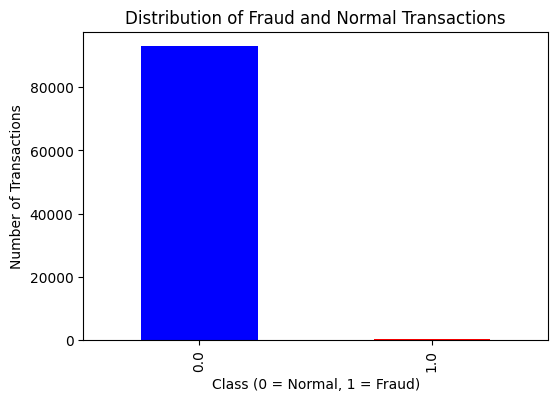

In [14]:
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
df["Class"].value_counts().plot(kind="bar", color=["blue", "red"])

plt.title("Distribution of Fraud and Normal Transactions")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Number of Transactions")
plt.show()

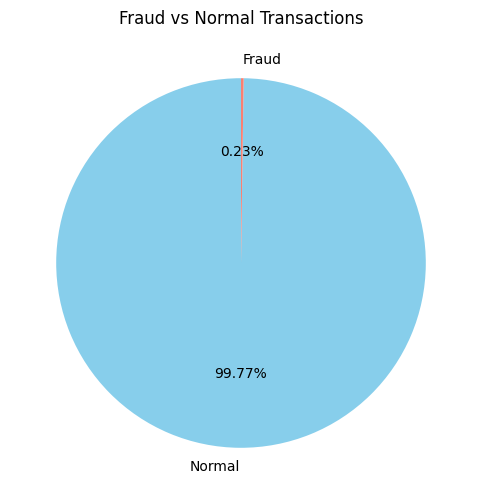

In [15]:
plt.figure(figsize=(6,6))

df["Class"].value_counts().plot(
    kind="pie",
    labels=["Normal", "Fraud"],
    autopct="%1.2f%%",
    startangle=90,
    colors=["skyblue", "salmon"]
)

plt.title("Fraud vs Normal Transactions")
plt.ylabel("")
plt.show()

Class Imbalance Analysis

The dataset is highly imbalanced. Most transactions are legitimate, while only a very small percentage are fraudulent. This imbalance makes fraud detection challenging because machine learning models may become biased toward predicting the majority class. Therefore, techniques such as SMOTE or class weighting are required to improve the detection of fraudulent transactions.

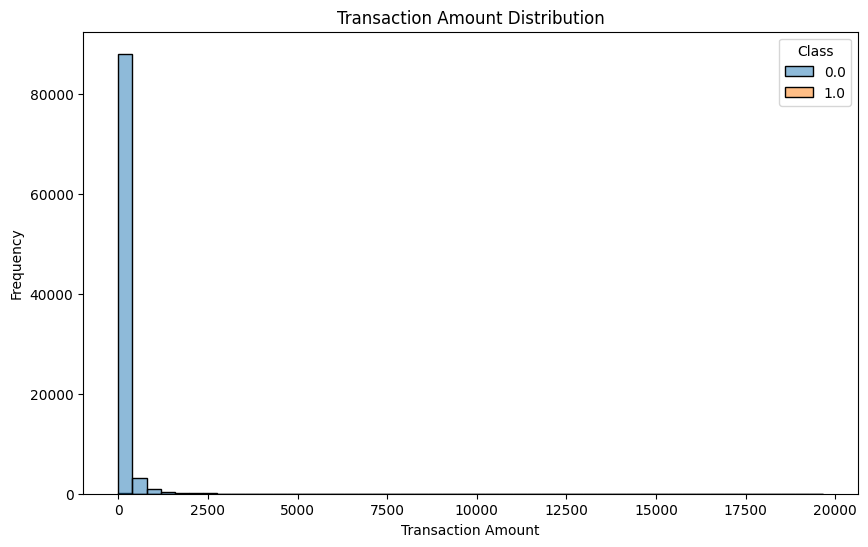

In [16]:
plt.figure(figsize=(10,6))

sns.histplot(data=df, x="Amount", hue="Class", bins=50)

plt.title("Transaction Amount Distribution")
plt.xlabel("Transaction Amount")
plt.ylabel("Frequency")

plt.show()

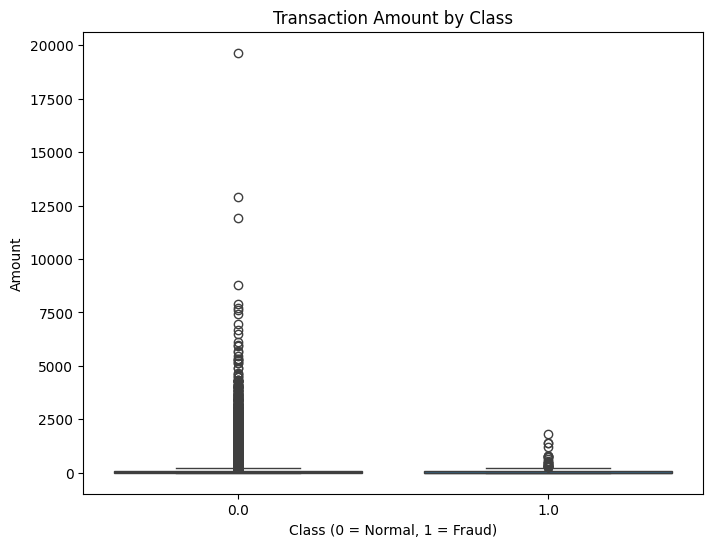

In [17]:
plt.figure(figsize=(8,6))

sns.boxplot(x="Class", y="Amount", data=df)

plt.title("Transaction Amount by Class")
plt.xlabel("Class (0 = Normal, 1 = Fraud)")
plt.ylabel("Amount")

plt.show()

In [18]:
df["Hour"] = (df["Time"] / 3600) % 24

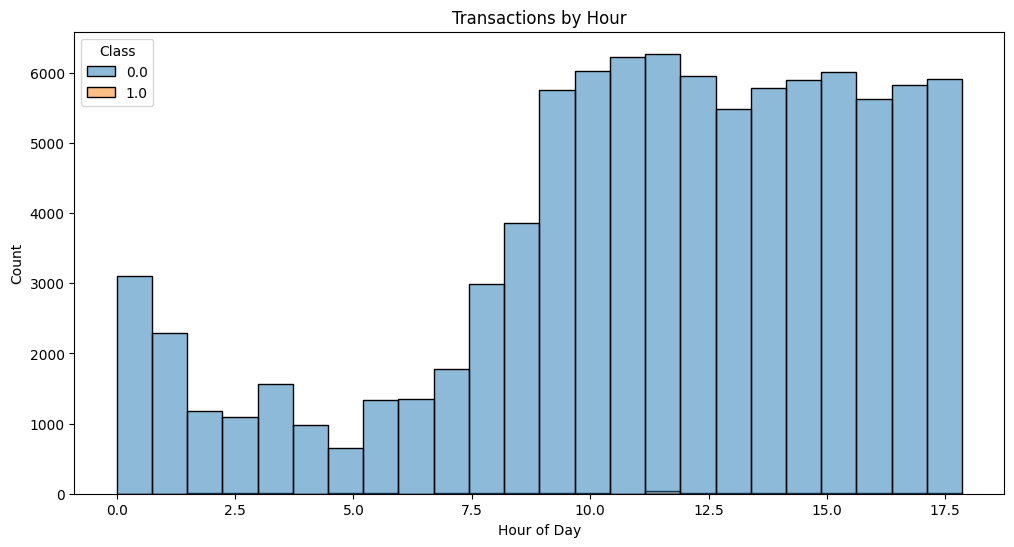

In [19]:
plt.figure(figsize=(12,6))

sns.histplot(data=df, x="Hour", hue="Class", bins=24)

plt.title("Transactions by Hour")
plt.xlabel("Hour of Day")
plt.ylabel("Count")

plt.show()

In [20]:
df.groupby("Class")["Amount"].mean()

,Amount
Class,
0.0,99.009344
1.0,108.459202


Exploratory Data Analysis (EDA)

The exploratory data analysis shows that the dataset contains a large imbalance between normal and fraudulent transactions. The transaction amount distribution indicates that most transactions involve relatively small amounts. The time-of-day analysis helps identify whether fraudulent transactions are concentrated during specific hours. These insights are useful for understanding the characteristics of fraud before building machine learning models.

Why Accuracy is Misleading

Fraud detection datasets are highly imbalanced because fraudulent transactions make up only a very small percentage of all transactions. If a model predicts every transaction as normal, it can still achieve over 99% accuracy while failing to detect any fraud. Therefore, accuracy alone is not a reliable metric. Instead, Precision, Recall, F1-Score, and ROC-AUC should be used to evaluate fraud detection models.

In [21]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

ValueError: Input y contains NaN.

In [23]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [24]:
df.isnull().sum().sum()

np.int64(18)

In [25]:
df = df.dropna()

In [26]:
df.isnull().sum()

,0
Time,0
V1,0
V2,0
V3,0
V4,0
V5,0
V6,0
V7,0
V8,0
V9,0


In [27]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [28]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [29]:
df.columns

Index(['Time', 'V1', 'V2', 'V3', 'V4', 'V5', 'V6', 'V7', 'V8', 'V9', 'V10',
       'V11', 'V12', 'V13', 'V14', 'V15', 'V16', 'V17', 'V18', 'V19', 'V20',
       'V21', 'V22', 'V23', 'V24', 'V25', 'V26', 'V27', 'V28', 'Amount',
       'Class', 'Hour'],
      dtype='object')

In [30]:
df["Class"].isnull().sum()

np.int64(0)

In [31]:
X = df.drop("Class", axis=1)
y = df["Class"]

In [32]:
print(y.isnull().sum())

0


In [33]:
print(y.dtype)

float64


In [34]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (74544, 31)
Test: (18636, 31)


In [35]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

In [36]:
print("Before SMOTE:")
print(y_train.value_counts())

print("\nAfter SMOTE:")
print(y_train_smote.value_counts())

Before SMOTE:
Class
0.0    74374
1.0      170
Name: count, dtype: int64

After SMOTE:
Class
0.0    74374
1.0    74374
Name: count, dtype: int64


In [37]:
from sklearn.linear_model import LogisticRegression

lr = LogisticRegression(max_iter=1000)

lr.fit(X_train_smote, y_train_smote)

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:465: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


LogisticRegression(max_iter=1000)

In [38]:
y_pred_lr = lr.predict(X_test)
y_prob_lr = lr.predict_proba(X_test)[:, 1]

In [39]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_lr))

              precision    recall  f1-score   support

         0.0       1.00      0.99      0.99     18593
         1.0       0.16      0.91      0.27        43

    accuracy                           0.99     18636
   macro avg       0.58      0.95      0.63     18636
weighted avg       1.00      0.99      0.99     18636



In [40]:
from sklearn.tree import DecisionTreeClassifier

dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train_smote, y_train_smote)

DecisionTreeClassifier(random_state=42)

In [41]:
y_pred_dt = dt.predict(X_test)
y_prob_dt = dt.predict_proba(X_test)[:,1]

In [42]:
from sklearn.metrics import classification_report

print(classification_report(y_test, y_pred_dt))

              precision    recall  f1-score   support

         0.0       1.00      1.00      1.00     18593
         1.0       0.57      0.86      0.69        43

    accuracy                           1.00     18636
   macro avg       0.78      0.93      0.84     18636
weighted avg       1.00      1.00      1.00     18636



In [43]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_test, y_pred_dt)

print(cm)

[[18565    28]
 [    6    37]]


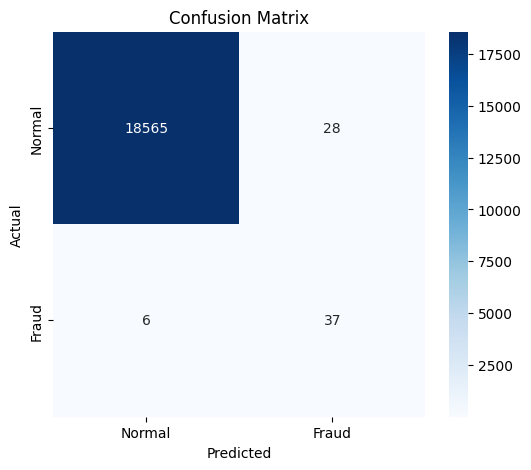

In [44]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(6,5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Normal","Fraud"],
    yticklabels=["Normal","Fraud"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")

plt.show()

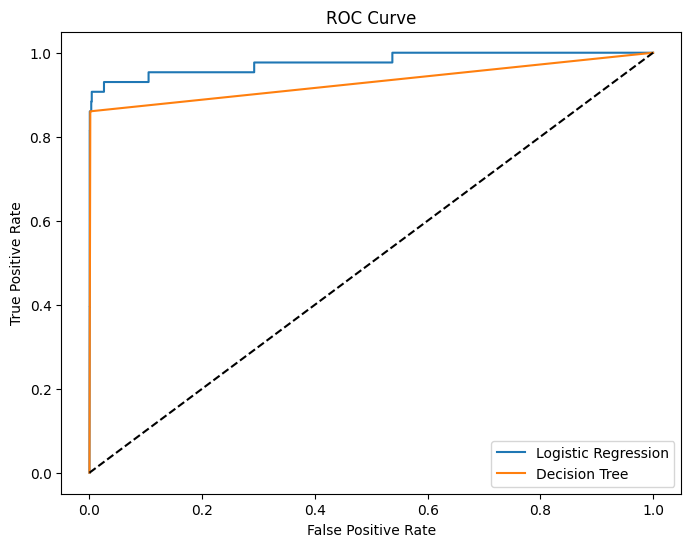

In [45]:
from sklearn.metrics import roc_curve

fpr_lr, tpr_lr, _ = roc_curve(y_test, y_prob_lr)
fpr_dt, tpr_dt, _ = roc_curve(y_test, y_prob_dt)

plt.figure(figsize=(8,6))

plt.plot(fpr_lr, tpr_lr, label="Logistic Regression")
plt.plot(fpr_dt, tpr_dt, label="Decision Tree")
plt.plot([0,1],[0,1],'k--')

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.legend()

plt.show()

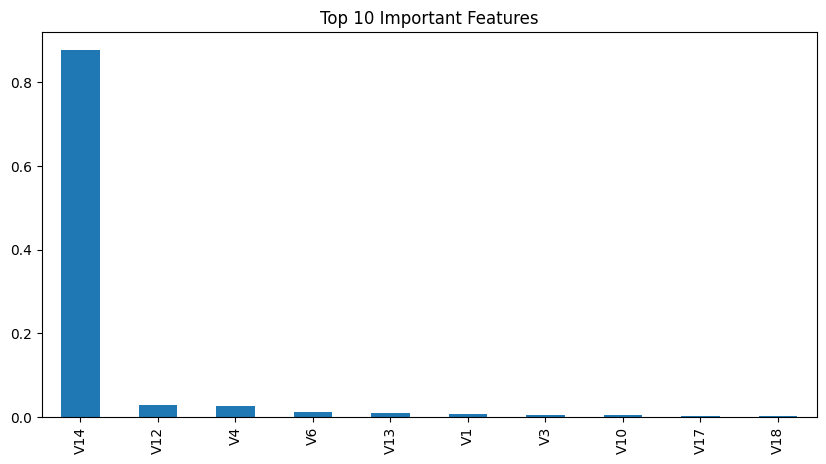

In [46]:
importance = pd.Series(
    dt.feature_importances_,
    index=X.columns
)

importance = importance.sort_values(ascending=False)

plt.figure(figsize=(10,5))

importance.head(10).plot(kind="bar")

plt.title("Top 10 Important Features")

plt.show()

In [47]:
from sklearn.metrics import precision_score, recall_score, f1_score, roc_auc_score

comparison = pd.DataFrame({
    "Model": ["Logistic Regression", "Decision Tree"],
    "Precision": [
        precision_score(y_test, y_pred_lr),
        precision_score(y_test, y_pred_dt)
    ],
    "Recall": [
        recall_score(y_test, y_pred_lr),
        recall_score(y_test, y_pred_dt)
    ],
    "F1-Score": [
        f1_score(y_test, y_pred_lr),
        f1_score(y_test, y_pred_dt)
    ],
    "ROC-AUC": [
        roc_auc_score(y_test, y_prob_lr),
        roc_auc_score(y_test, y_prob_dt)
    ]
})

comparison

,Model,Precision,Recall,F1-Score,ROC-AUC
0,Logistic Regression,0.156000,0.906977,0.266212,0.977216
1,Decision Tree,0.569231,0.860465,0.685185,0.929480


Recall vs Precision

Recall is the most important metric in fraud detection because it measures how many actual fraudulent transactions are correctly identified. Missing a fraudulent transaction can result in financial losses, making high recall essential. Precision is also important because a low precision means many legitimate transactions are incorrectly flagged as fraud, increasing investigation costs. Therefore, an effective fraud detection system should aim for high recall while maintaining good precision.

Scalability

To handle one million transactions per hour, the fraud detection model can be deployed as a real-time prediction service using cloud platforms. Distributed processing frameworks such as Apache Spark and message streaming tools such as Apache Kafka can process transactions in parallel. The model should also be retrained regularly with new transaction data to adapt to evolving fraud patterns.

Conclusion

This project developed a machine learning pipeline for detecting fraudulent financial transactions using an imbalanced dataset. SMOTE was applied to balance the training data before model training. Logistic Regression and Decision Tree models were trained and evaluated using Precision, Recall, F1-Score, and ROC-AUC. The results demonstrate that appropriate evaluation metrics and class imbalance handling techniques are essential for building reliable fraud detection systems.